In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('/kaggle/input/datasets/organizations/chicago/chicago-taxi-rides-2016/chicago_taxi_trips_2016_01.csv')

In [3]:
df.head()

,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare,tips,tolls,extras,trip_total,payment_type,company,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
0,85.0,2016-1-13 06:15:00,2016-1-13 06:15:00,180.0,0.40,NaN,NaN,24.0,24.0,4.50,0.00,0.0,0.0,4.50,Cash,107.0,199.0,510.0,199.0,510.0
1,2776.0,2016-1-22 09:30:00,2016-1-22 09:45:00,240.0,0.70,NaN,NaN,NaN,NaN,4.45,4.45,0.0,0.0,8.90,Credit Card,NaN,NaN,NaN,NaN,NaN
2,3168.0,2016-1-31 21:30:00,2016-1-31 21:30:00,0.0,0.00,NaN,NaN,NaN,NaN,42.75,5.00,0.0,0.0,47.75,Credit Card,119.0,NaN,NaN,NaN,NaN
3,4237.0,2016-1-23 17:30:00,2016-1-23 17:30:00,480.0,1.10,NaN,NaN,6.0,6.0,7.00,0.00,0.0,0.0,7.00,Cash,NaN,686.0,500.0,686.0,500.0
4,5710.0,2016-1-14 05:45:00,2016-1-14 06:00:00,480.0,2.71,NaN,NaN,32.0,NaN,10.25,0.00,0.0,0.0,10.25,Cash,NaN,385.0,478.0,NaN,NaN


In [4]:
df.isnull().sum()

taxi_id                        23
trip_start_timestamp            0
trip_end_timestamp            125
trip_seconds                  314
trip_miles                     14
pickup_census_tract       1705805
dropoff_census_tract       738326
pickup_community_area      285789
dropoff_community_area     313655
fare                           33
tips                           33
tolls                          33
extras                         33
trip_total                     33
payment_type                    0
company                    632726
pickup_latitude            285757
pickup_longitude           285757
dropoff_latitude           311682
dropoff_longitude          311682
dtype: int64

In [5]:
#drop rows where either trip_miles or fare has NaN
df = df.dropna(subset=['trip_miles','fare'])

#x must be a dataframe(2d array) for scikit-learn
x=df[['trip_miles']]

#y is be a series(1d array)
y=df['fare']

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
print(f"Training set size: {x_train.shape[0]}")
print(f"Testing set size: {x_test.shape[0]}")

Training set size: 1364606
Testing set size: 341152


In [8]:
mdl = LinearRegression()
mdl.fit(x_train, y_train)

print(f"Intercept: {mdl.intercept_:.2f}")
print(f"Coefficient: {mdl.coef_[0]:.2f}")

Intercept: 12.70
Coefficient: 0.15


In [9]:
y_pred = mdl.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"r2: {r2:.2f}")

MSE: 1270.64
r2: 0.01


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


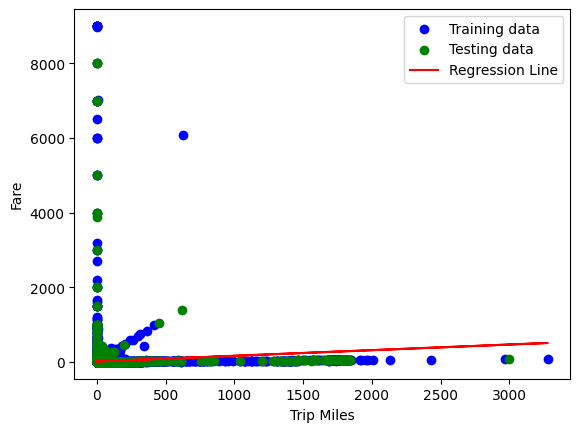

In [10]:
plt.scatter(x_train,y_train, color = 'blue', label = 'Training data' )
plt.scatter(x_test,y_test, color = 'green', label = 'Testing data' )
#plot prediction for entire dataset
plt.plot(x, mdl.predict(x), color = 'red', label = 'Regression Line')
plt.xlabel('Trip Miles')
plt.ylabel('Fare')
plt.legend()

plt.show()